<a href="https://colab.research.google.com/github/ReDanBorn/MathStat/blob/main/3_%D0%A0%D0%B0%D1%81%D0%BF%D1%80%D0%B5%D0%B4%D0%B5%D0%BB%D0%B5%D0%BD%D0%B8%D1%8F_%D0%B2_%D0%B1%D0%B8%D0%B1%D0%BB%D0%B8%D0%BE%D1%82%D0%B5%D0%BA%D0%B5_SciPy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Библиотека SciPy


Многие задачи из различных математических дисциплин решаются с использованием пакетов библиотеки ```SciPy```.

## Материал

Рассмотрим небольшой пример, как можно работать с непрерывными случайными величинами и какими основными методами обладает распределение случайных величин, какую информацию можно извлекать, чем можно пользоваться.

Список всех функций теории вероятностей и математической статистике доступен по [ссылке](https://docs.scipy.org/doc/scipy/reference/stats.html).

Главные методы непрерывной случайной величины:

*   rvs: Random Variates

*   pdf: функция плотности

*   cdf: функция распределения

*   sf: Survival Function (1-CDF)

*   ppf: Percent Point Function (Inverse of CDF)

*   isf: Inverse Survival Function (Inverse of SF)

*   stats: получение среднего(mean), дисперсии(variance), скошенности(skew), эксцесса(kurtosis)

*   moment: моменты распределения


In [54]:
from pygments.styles.dracula import background
# Импортируем модуль stats
from scipy import stats
import numpy as np

In [55]:
stats.norm.cdf(0)                     # Функция нормального распределения в точке 0

np.float64(0.5)

In [56]:
stats.norm.cdf([-1., 0, 1])           # Функция нормального распределения, подаем сразу несколько значений

array([0.15865525, 0.5       , 0.84134475])

Сравним скорость работы.

In [57]:
%timeit np.random.normal(size=10000)  # Замерим скорость работы операции с помощью модуля random библиотеки Numpy

185 μs ± 3.15 μs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


In [58]:
%timeit stats.norm.rvs(size=10000)    # Замерим скорость работы операции с помощью модуля stats библиотеки SciPy

215 μs ± 35.2 μs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


Видим, что модуль random библиотеки Numpy работает немного быстрее. Но методы непрерывной случайной величины позволяют гораздо шире работать с функциями распределений, библиотека SciPy будет удобнее при работе со случайными величинами.



---


Рассмотрим базовые понятия теории вероятностей и методы модуля scipy.stats, позволяющих решать задачи теории вероятностей и математической статистики.


---



#### Ключевые слова, понятия и выражения






*   случайная величина
*   функция плотности распределения
*   функция распределения
*   мода, медиана, математическое ожидание, дисперсия
*   статистический критерий

#### 1.Основные распределения случайных величин, встречающихся в теории вероятности
  
  
   

##### 1.1 Определение функции плотности и функции распределения случайной величины. Построение графиков

Подробно разберем на примере нормального распределения. Для остальных распределений оставим только короткие комментарии.

In [59]:
# Работа с массивами данных
import numpy as np

# Импортируем библиотеку matplotlib
import matplotlib.pyplot as plt
%matplotlib inline

# Импортируем модуль stats
import scipy.stats as sts

* **Нормальное распределение**

Сгенерируем выборку из нормально распределённой случайной величины с параметрами среднего $\mu=0.0$ и среднеквадратичным отклонением $\sigma=1.0$:

In [60]:
# Инициализируем параметры
mu = 0.0
sigma = 1.0

# Зададим нормально распределенную случайную величину
norm_rv = sts.norm(loc=mu, scale=sigma)

# Сгенерируем 10 значений
norm_rv.rvs(size=10)

array([-0.24688947, -1.83548796, -0.38380662, -2.55820867, -0.08611803,
        0.96128448,  1.94004054, -0.12295611, -1.07813894, -0.25417779])

Для нахождения значения функции распределения случайной величины в точке можно сделать так:

In [61]:
# cdf() - функция распределения
norm_rv.cdf(0)

np.float64(0.5)

Теперь можно поточечно построить **функцию распределения**:

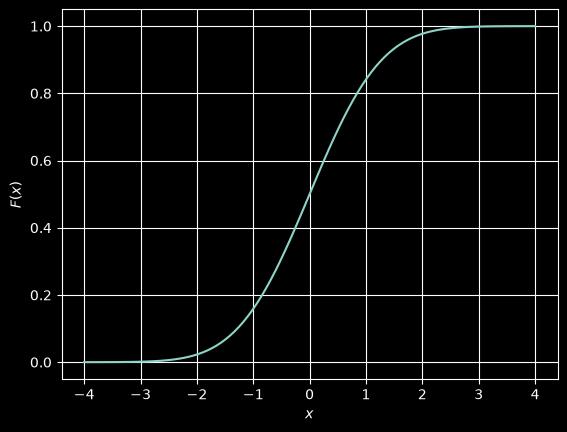

In [62]:
# Получаем массив из 100 аргументов x из отрезка [-4, 4] и значений функции распределения
x = np.linspace(-4, 4, 100)   # Обратите внимание, что мы брали среднее равным 0.0
cdf = norm_rv.cdf(x)          # Функция может принимать и вектор (x)

# Построим график
plt.plot(x, cdf)              # Подаем данные plt.plot для отрисовки графика
plt.ylabel('$F(x)$')          # Подписываем ось y
plt.grid()                    # Выводим координатную сетку графика
plt.xlabel('$x$')             # Подписываем ось x
plt.show()                    # Выводим на экран

Построим график **функции плотности** вероятности:

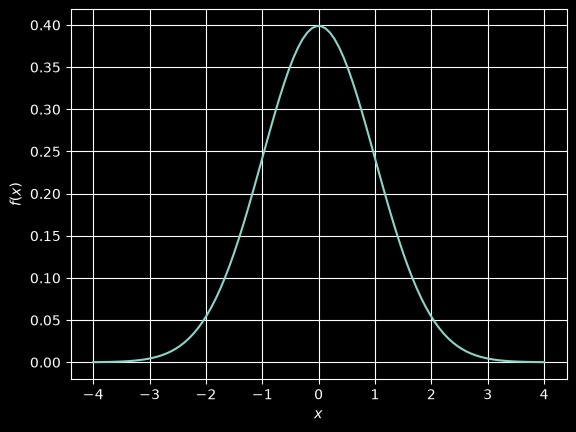

In [63]:
x = np.linspace(-4, 4, 100)   # Получаем массив из 100 аргументов x из отрезка [-4, 4] и значений функции распределения
pdf = norm_rv.pdf(x)          # Получаем значения функции плотности pdf()

# Построим график
plt.plot(x, pdf)              # Подаем данные plt.plot для отрисовки графика
plt.grid()                    # Выводим координатную сетку графика
plt.ylabel('$f(x)$')          # Подписываем ось y
plt.xlabel('$x$')             # Подписываем ось x
plt.show()                    # Выводим на экран

По графику можно сказать следующее - там, где всречаются максимумы, значения, которые будут генерироваться, находятся в интервале от -1 до 1. Значения от 3 и выше будут всречаться очень редко.

Напомним, что функция распределения и функция плотности связаны следующим соотношением:
$$F(x)=\int_{-\infty}^x f(t)dt$$
Быстро проверим это:

In [64]:
# Алгоритм подсчета определенного интеграла "на коленке"
def integral(f, a, b, dx=0.01):
    n = int((b - a) / dx)
    x = a
    sum = 0.0
    for i in range(n):
        sum += f(x) * dx
        x += dx
    return sum

In [65]:
# Посчитаем интеграл для функции плотности от минус бесконечности ( -5 :) ) до x0
x0 = 5.0
print('Значение интеграла функции плотности: {}'.format(round(integral(norm_rv.pdf, -5, x0, 0.01), 2)))

# Сравним со значением функции распределения
print('Значение функции распределения: {}'.format(round(norm_rv.cdf(x0), 2)))

Значение интеграла функции плотности: 1.0
Значение функции распределения: 1.0


* **Равномерное распределение**

In [66]:
# Случайно выбираем точку на отрезке [1, 4]
a = 1
b = 4

# Обратите внимание, что в этой функции задается левая граница и масштаб, а не левая и правая границы:
uniform_rv = sts.uniform(a, b - a)

# Сгенерируем 10 значений
uniform_rv.rvs(10)

array([1.43712076, 1.36235769, 2.47254454, 2.55976357, 3.24254422,
       1.62464743, 3.93221958, 3.41764922, 3.13849465, 3.27617455])

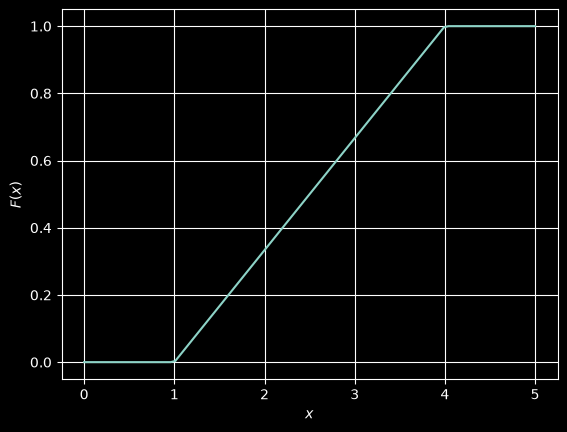

In [67]:
# функция распределения
x = np.linspace(0, 5, 100)    # Получаем массив из 100 аргументов x
cdf = uniform_rv.cdf(x)       # Получаем значения функции распределения

# Построим график
plt.plot(x, cdf)              # Подаем данные plt.plot для отрисовки графика
plt.grid()                    # Выводим координатную сетку графика
plt.ylabel('$F(x)$')          # Подписываем ось y
plt.xlabel('$x$')             # Подписываем ось x
plt.show()                    # Выводим на экран

AttributeError: Line2D.set() got an unexpected keyword argument 'background'

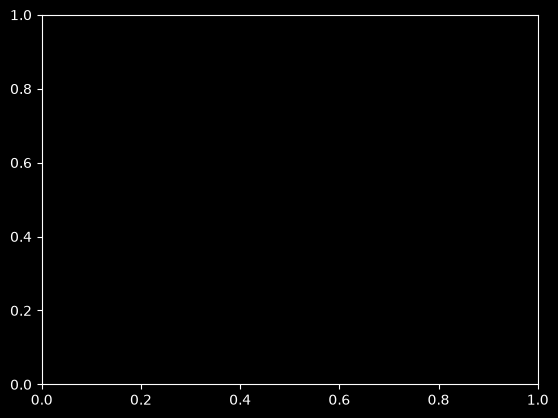

In [68]:
# функция плотности
x = np.linspace(0, 5, 1000)   # Получаем массив из 100 аргументов x
pdf = uniform_rv.pdf(x)       # Получаем значения функции плотности pdf()

# Построим график
plt.plot(x, pdf, background='')              # Подаем данные plt.plot для отрисовки графика
plt.grid()                    # Выводим координатную сетку графика
plt.ylabel('$f(x)$')          # Подписываем ось y
plt.xlabel('$x$')             # Подписываем ось x
plt.show()                    # Выводим на экран

* **Биномиальное распределение**

In [ ]:
# Генерация 10 значений выборки,каждое из которых является числом успехов в серии из 20 одинаковых
# независимых испытаний Бернулли с вероятностью успеха 0.7 в каждом испытании
binomial_rv = sts.binom(20, 0.7)
binomial_rv.rvs(10)

In [ ]:
# Функция распределения
x = np.linspace(0, 20, 21)    # Получаем массив из аргументов x
cdf = binomial_rv.cdf(x)      # Получаем значения функции распределения

# Построим график
plt.step(x, cdf)              # Подаем данные plt.step для отрисовки графика
plt.grid()                    # Выводим координатную сетку графика
plt.ylabel('$F(x)$')          # Подписываем ось y
plt.xlabel('$x$')             # Подписываем ось x
plt.show()                    # Выводим на экран

Функция **вероятности** pmf() для дискретных случайных величин заменяет функцию плотности pdf():

In [ ]:
x = np.linspace(0, 20, 21)    # Получаем массив из аргументов x
pmf = binomial_rv.pmf(x)      # Получаем значения функции

# Построим график
plt.plot(x, pmf, 'o')         # Подаем данные plt.plot для отрисовки графика
plt.ylabel('$P(X=x)$')        # Подписываем ось y
plt.xlabel('$x$')             # Подписываем ось x
plt.show()                    # Выводим на экран

* **Распределение Пуассона**

In [ ]:
# Число событий, произошедших за фиксированное время, при условии, что данные события
# происходят с некоторой фиксированной средней интенсивностью и независимо друг от друга
poisson_rv = sts.poisson(5)
poisson_rv.rvs(10)

In [ ]:
# Поизменяем значение параметра лямбда
x = np.linspace(0, 30, 31)    # Получаем массив из аргументов x

# Построим графики
for l in [1, 5, 10, 15]:
    rv = sts.poisson(l)
    cdf = rv.cdf(x)
    plt.step(x, cdf, label="$\lambda=%s$" % l)  # Подаем данные plt.step для отрисовки графиков

plt.legend()                  # Выводим легенду
plt.title("CDF (poisson)")    # Задаем название графика
plt.ylabel('$F(x)$')          # Подписываем ось y
plt.xlabel('$x$')             # Подписываем ось x
plt.show()                    # Выводим на экран

In [ ]:
x = np.linspace(0, 30, 31)    # Получаем массив из аргументов x
symbols = iter(['o', 's', '^', '+'])  # Задаем символы отрисовки графиков

# Построим графики
for l in [1, 5, 10, 15]:
    rv = sts.poisson(l)
    pmf = rv.pmf(x)
    plt.plot(x, pmf, next(symbols), label="$\lambda=%s$" % l) # Подаем данные plt.plot для отрисовки графиков

plt.legend()                  # Выводим легенду
plt.title("PMF (poisson)")    # Задаем название графика
plt.ylabel('$P(X=x)$')        # Подписываем ось y
plt.xlabel('$x$')             # Подписываем ось x
plt.show()                    # Выводим на экран

* **Распределение Хи-квадрат**

In [ ]:
# функция распределения
x = np.linspace(0, 30, 100)    # Получаем массив из аргументов x

# Построим графики
for k in [1, 2, 3, 4, 6, 9]:
    rv = sts.chi2(k)
    cdf = rv.cdf(x)
    plt.plot(x, cdf, label="$k=%s$" % k)  # Подаем данные plt.plot для отрисовки графиков

plt.legend()                  # Выводим легенду
plt.title("CDF ($\chi^2_k$)") # Задаем название графика
plt.show()                    # Выводим на экран

In [ ]:
# Функция плотности
x = np.linspace(0, 30, 100)   # Получаем массив из аргументов x

# Построим графики
for k in [1, 2, 3, 4, 6, 9]:
    rv = sts.chi2(k)
    pdf = rv.pdf(x)
    plt.plot(x, pdf, label="$k=%s$" % k)  # Подаем данные plt.plot для отрисовки графиков

plt.legend()                  # Выводим легенду
plt.title("PDF ($\chi^2_k$)") # Задаем название графика
plt.show()                    # Выводим на экран

##### 1.2 Основные характеристики случайной величины: математическое ожидание, мода, медиана, дисперсия,        среднеквадратичное отклонение

Разберем понятия **математического ожидания** и **среднеквадратичного отклонения** на примере нормального распределения, а именно, займемся их визуализацией на графике плотности.

In [ ]:
x = np.linspace(-4, 4, 100)   # Получаем массив из аргументов x
pdf = norm_rv.pdf(x)          # Получаем значения функции плотности pdf()

# Построим график
plt.plot(x, pdf)              # Подаем данные plt.plot для отрисовки графика
plt.title("Среднее и среднеквадратичное отклонение на графике плотности нормального распределения")  # Задаем название графика

# Отрисовываем среднее и отклонения от среднего на одну сигму
plt.axvline(x=norm_rv.mean(), color='y', linestyle='--', label='mean')
plt.axvline(x=norm_rv.mean() + norm_rv.std(), color='r', linestyle='--', label='+-std')
plt.axvline(x=norm_rv.mean() - norm_rv.std(), color='r', linestyle='--')

plt.ylabel('$f(x)$')          # Подписываем ось y
plt.xlabel('$x$')             # Подписываем ось x
plt.legend()                  # Выводим легенду
plt.show()                    # Выводим на экран

В случае нормального распределения среднее, медиана и мода совпадают, что не интересно. На примере распределения Хи-квадрат покажем, как могут располагаться указанные значения в более общем случае.

In [ ]:
# Генерирум выборку
x = np.linspace(0, 30, 100)   # Получаем массив из аргументов x
chi2_rv= sts.chi2(10)         # Получаем массив из 10 аргументов
pdf = chi2_rv.pdf(x)          # Получаем значения функции плотности pdf()

# Построим график плотности
plt.plot(x, pdf, label='$\chi^2_{10}$') # Подаем данные plt.plot для отрисовки графика
plt.title("Основные характеристики на графике плотности распределения $\chi^2_{10}$")  # Задаем название графика

# Находим среднее
plt.axvline(x=chi2_rv.mean(), color='y', linestyle='--', label='mean')

# Находим медиану
plt.axvline(x=chi2_rv.median(), color='g', linestyle='--', label='median')

# Находим моду
plt.axvline(x=x[np.argmax(pdf)], color='b', linestyle='--', label='mode')

# Определяем разброс от среднего в пределах одной сигмы
plt.axvline(x=chi2_rv.mean() + chi2_rv.std(), color='r', linestyle='--',label='std')
plt.axvline(x=chi2_rv.mean() - chi2_rv.std(), color='r', linestyle='--')
plt.legend()                  # Выводим легенду
plt.show()                    # Выводим на экран

#### 2.Элементы статистики



##### 2.1 Выборка и ее характеристики. Построение гистограммы

Сгенерируем выборку объёма 100 из стандартного нормального распределения (с $\mu=0$ и $\sigma^2=1$):

In [ ]:
norm_rv = sts.norm(0, 1)
sample = norm_rv.rvs(100)

Построим эмпирическую функцию распределения для полученной выборки:

In [ ]:
x = np.linspace(-4, 4, 100)   # Получаем массив из аргументов x
cdf = norm_rv.cdf(x)          # Получаем значения функции распределения

# Построим график
plt.plot(x, cdf, label='theoretical CDF') # Подаем данные plt.plot для отрисовки графика

# Для построения ECDF используем библиотеку statsmodels
from statsmodels.distributions.empirical_distribution import ECDF

ecdf = ECDF(sample)

plt.step(ecdf.x, ecdf.y, label='ECDF')  # Подаем данные plt.step для отрисовки графика
plt.ylabel('$f(x)$')          # Подписываем ось y
plt.xlabel('$x$')             # Подписываем ось x
plt.legend(loc='upper left')  # Задаем расположение вывода легенды
plt.show()                    # Выводим на экран

Построим гистограмму:

In [ ]:
# Важно угадать с параметром bins - количество интервалов,
# на которые разбивается выборка для подсчета частот элементов
plt.hist(sample, bins=5)      # Подаем данные plt.hist для отрисовки графика
plt.ylabel('fraction of samples') # Подписываем ось y
plt.xlabel('$x$')             # Подписываем ось x
plt.show()                    # Выводим на экран

Для получения "гладкой" функции плотности можно воспользоваться ядерным сглаживанием:

In [ ]:
# Сглаживание
kde = sts.gaussian_kde(sample)

# Построим график
plt.plot(x, kde(x), label='KDE') # Подаем данные plt.plot для отрисовки графика

# Построение теоретической функции плотности
pdf = norm_rv.pdf(x)

# Построим график
plt.plot(x, pdf, label='theoretical PDF') # Подаем данные plt.plot для отрисовки графика
plt.legend()                  # Выводим легенду
plt.show()                    # Выводим на экран

### -----------[[[Самостоятельная работа 3]]]-----------

In [ ]:
# import kagglehub
#
# # Download latest version
# path = kagglehub.dataset_download("aadarshvelu/heart-failure-prediction-clinical-records", output_dir="./DataSets/")
#
# print("Path to dataset files:", path)